## Exercise 3

Load in the data "energySoftware.csv" and answer the following questions:
1. Plot the distribution of CPU for each test type

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from scipy import stats

# Load the CSV
energy_data = pd.read_csv("energySoftware.csv")
energy_data.head()
# energy_data.info()

,test,PKG,CPU,nn,nn2,time
0,bubblesort,0.010986,0.009155,,,3.165
1,bubblesort,0.013184,0.010925,,,3.069
2,bubblesort,0.015198,0.009399,,,2.617
3,bubblesort,0.010559,0.009583,,,2.572
4,bubblesort,0.009949,0.009949,,,2.671


2. Is there a difference in the CPU between bubblesort and bubblesort_ll? (note that the last name contains two small l's and not two capital i's) Justify your choice of test(s). 


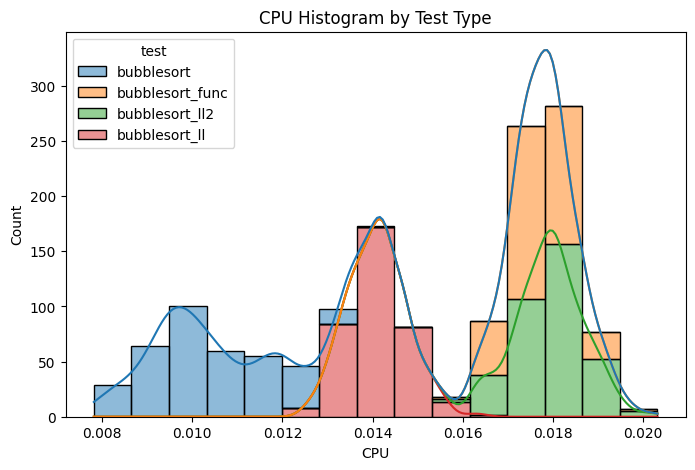

In [ ]:
# plt.figure(figsize=(8,5))
# sns.boxplot(data=energy_data, x="test_type", y="CPU")
# plt.title("CPU Distribution by Test Type")
# plt.xticks(rotation=45)
# plt.show()

# Optional: KDE plots for more visual insight
plt.figure(figsize=(8,5))
sns.histplot(data=energy_data, x="CPU", hue="test", kde=True, multiple="stack")
plt.title("CPU Histogram by Test Type")
plt.show()

3. Is there a difference in the CPU between bubblesort_func and bubblesort_ll2? Justify your choice of test(s). If there is a difference, how big is it?


In [ ]:
cpu_bubblesort = energy_data.loc[energy_data["test"] == "bubblesort", "CPU"]
cpu_bubblesort_ll = energy_data.loc[energy_data["test"] == "bubblesort_ll", "CPU"]
u_stat, p_value = stats.mannwhitneyu(cpu_bubblesort, cpu_bubblesort_ll, alternative="two-sided")
print(f"Mann–Whitney U test: U-statistic = {u_stat}, p_value = {p_value:.4f}")


Mann–Whitney U test: U-statistic = 645.5, p_value = 0.0000


Step 5: Conclusion

H₀: CPU distributions are the same

H₁: CPU distributions differ

α = 0.05

Interpret p-value: if p < 0.05 → significant difference.

In [ ]:
cpu_func = energy_data.loc[energy_data["test"] == "bubblesort_func", "CPU"]
cpu_ll2 = energy_data.loc[energy_data["test"] == "bubblesort_ll2", "CPU"]

# Mann–Whitney U test
u_stat, p_value = stats.mannwhitneyu(cpu_func, cpu_ll2, alternative="two-sided")
u_stat, p_value

(np.float64(50920.5), np.float64(6.502153741813431e-07))

In [ ]:
# Compute difference in medians
median_diff = cpu_func.median() - cpu_ll2.median()
median_diff
# Interpretation: This tells you how large the difference is in CPU between these two methods.

np.float64(-0.00030517578125)

Interpretation: This tells you how large the difference is in CPU between these two methods.

4. When it comes to time, is there a difference between bubblesort and bubblesort_ll? Justify your choice of test(s).


In [ ]:
time_bubblesort = energy_data.loc[energy_data["test"] == "bubblesort", "time"]
time_bubblesort_ll = energy_data.loc[energy_data["test"] == "bubblesort_ll", "time"]

# Mann–Whitney U test (non-parametric)
u_stat, p_value = stats.mannwhitneyu(time_bubblesort, time_bubblesort_ll, alternative="two-sided")
u_stat, p_value

(np.float64(74960.0), np.float64(0.00035855213302219286))

5. Perform an ANOVA test to test if there is a difference in means across groups for time

In [ ]:
# Step 1: Prepare data

groups = [group["time"].dropna() for _, group in energy_data.groupby("test")]

# Step 2: Check assumptions

# Normality within each group (Shapiro test)
# Homogeneity of variance (Levene test)

for name, group in energy_data.groupby("test"):
    stat, p = stats.shapiro(group["time"])
    print(f"{name}: Shapiro p-value = {p:.4f}")

stat, p = stats.levene(*groups)
print(f"Levene test p-value = {p:.4f}")

# Step 3: Perform ANOVA

f_stat, p_value = stats.f_oneway(*groups)
f_stat, p_value

bubblesort: Shapiro p-value = 0.0000
bubblesort_func: Shapiro p-value = 0.0000
bubblesort_ll: Shapiro p-value = 0.0000
bubblesort_ll2: Shapiro p-value = 0.0000
Levene test p-value = 0.0000


(np.float64(2556.3329354127864), np.float64(0.0))

Step 4: Interpretation

H₀: Means of time are equal across all test types

H₁: At least one mean differs

α = 0.05

If p < 0.05 → significant difference.